In [1]:

"""
fig_matriz_decision.py
======================
Matriz de decision del Capitulo 6: clase de susceptibilidad (filas) x
clase de lluvia (columnas) -> nivel de alerta I-IV.
 
Regla (ver texto de Metodos):
  1. La lluvia fija el nivel base: nivel = clase de lluvia.
  2. Con lluvia baja, todas las unidades quedan en nivel I.
  3. La susceptibilidad desplaza el nivel un paso, de forma asimetrica:
       muy alta  -> +1 desde lluvia moderada
       baja      -> -1 solo desde lluvia alta
     Media y alta no desplazan.
 
Tamano: la figura se dibuja a su tamano de impresion. CELL fija el lado
de cada celda en pulgadas; el lienzo se calcula a partir de CELL y de
los limites del dibujo, asi que no queda margen vacio. En LaTeX se
incluye sin 'width' y el texto conserva sus puntos (9-10.5 pt).
 
Salida: fig_matriz_decision.pdf (vectorial, para LaTeX) y .png (300 dpi).
"""
 
from pathlib import Path
 
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb
from matplotlib.patches import FancyBboxPatch
 
# ---------------------------------------------------------------------
# Datos de la matriz
# ---------------------------------------------------------------------
RAIN = ["Low", "Moderate", "High", "Very high"]   # columnas
SUSC = ["Low", "Moderate", "High", "Very high"]   # filas, de abajo arriba
 
# LEVEL[s][r]: fila = susceptibilidad (0 = Low), columna = lluvia (0 = Low)
LEVEL = [
    [1, 2, 2, 3],   # Low
    [1, 2, 3, 4],   # Moderate
    [1, 2, 3, 4],   # High
    [1, 3, 4, 4],   # Very high
]
BASE = [1, 2, 3, 4]   # nivel = clase de lluvia, sin ajuste
 
ROMAN = {1: "I", 2: "II", 3: "III", 4: "IV"}
 
# ---------------------------------------------------------------------
# Colores
# ---------------------------------------------------------------------
# Paleta base aclarada al 80 %: el mismo tono que alpha=0.8 sobre blanco,
# pero como color solido. Celdas y leyenda coinciden exactamente y el
# PDF no lleva transparencias.
BASE_FILL = {1: "#2E7D32", 2: "#F9A825", 3: "#EF6C00", 4: "#C62828"}
TINT = 0.80
 
INK = "#1a1a19"
MUTED = "#6b6b6b"
WHITE = "#ffffff"
 
 
def tint(color, t):
    """Mezcla `color` con blanco: t = 1 es el color puro, t = 0 es blanco."""
    return to_hex([t * c + (1.0 - t) for c in to_rgb(color)])
 
 
def contrast(c1, c2):
    """Razon de contraste WCAG 2.x entre dos colores (1 a 21)."""
    def lum(c):
        lin = [v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4
               for v in to_rgb(c)]
        return 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    hi, lo = sorted([lum(c1), lum(c2)], reverse=True)
    return (hi + 0.05) / (lo + 0.05)
 
 
FILL = {lvl: tint(c, TINT) for lvl, c in BASE_FILL.items()}
INK_ON = {1: INK, 2: INK, 3: INK, 4: WHITE}
 
# Los numerales (17 pt, negrita) son "texto grande": piden >= 3:1.
for lvl in FILL:
    ratio = contrast(FILL[lvl], INK_ON[lvl])
    if ratio < 3.0:
        print(f"Aviso: nivel {ROMAN[lvl]} con contraste {ratio:.1f}:1 (< 3:1)")
 



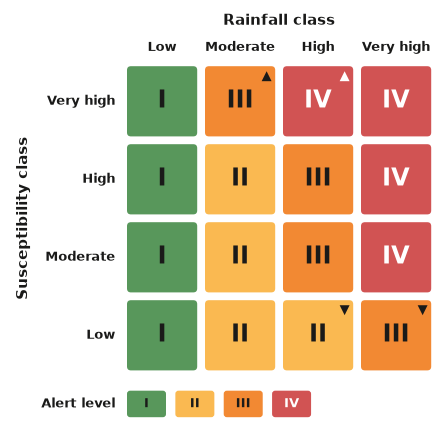

In [3]:
# ---------------------------------------------------------------------
# Geometria (unidades de datos: 1 = paso de una celda)
# ---------------------------------------------------------------------
CELL = 0.78       # pulgadas por celda; cambia esto para escalar todo
GAP = 0.05        # separacion entre celdas, a cada lado
LABEL_X = -0.10   # borde derecho de las etiquetas de fila
TITLE_X = -1.28   # titulo rotado "Susceptibility class"
XLIM = (-1.45, 4.00)
YLIM = (-0.65, 4.68)
 
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9,
                     "pdf.fonttype": 42})   # fuentes TrueType en el PDF
 
fig = plt.figure(figsize=((XLIM[1] - XLIM[0]) * CELL,
                          (YLIM[1] - YLIM[0]) * CELL))
ax = fig.add_axes([0, 0, 1, 1])   # el eje ocupa todo el lienzo
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_aspect("equal")
ax.axis("off")
 
# --- Celdas -----------------------------------------------------------
for s in range(4):
    for r in range(4):
        lvl = LEVEL[s][r]
        ax.add_patch(FancyBboxPatch(
            (r + GAP, s + GAP), 1 - 2 * GAP, 1 - 2 * GAP,
            boxstyle="round,pad=0,rounding_size=0.05",
            facecolor=FILL[lvl], edgecolor="none"))
        ax.text(r + 0.5, s + 0.5, ROMAN[lvl], ha="center", va="center",
                fontsize=17, fontweight="bold", color=INK_ON[lvl])
        shift = lvl - BASE[r]
        if shift != 0:
            ax.text(r + 0.84, s + 0.82, "▲" if shift > 0 else "▼",
                    ha="center", va="center", fontsize=9, color=INK_ON[lvl])
 
# --- Encabezados de columnas (lluvia) ---------------------------------
for r, name in enumerate(RAIN):
    ax.text(r + 0.5, 4.19, name, ha="center", va="center",
            fontsize=9.5, fontweight="bold", color=INK)
ax.text(2.0, 4.53, "Rainfall class", ha="center", va="center",
        fontsize=10.5, fontweight="bold", color=INK)
 
# --- Encabezados de filas (susceptibilidad) ---------------------------
for s, name in enumerate(SUSC):
    ax.text(LABEL_X, s + 0.5, name, ha="right", va="center",
            fontsize=9.5, fontweight="bold", color=INK)
ax.text(TITLE_X, 2.0, "Susceptibility class", ha="center", va="center",
        rotation=90, fontsize=10.5, fontweight="bold", color=INK)
 
# --- Leyenda ----------------------------------------------------------
ax.text(LABEL_X, -0.38, "Alert level", ha="right", va="center",
        fontsize=9, fontweight="bold", color=INK)
for i, lvl in enumerate([1, 2, 3, 4]):
    x0 = GAP + i * 0.62
    ax.add_patch(FancyBboxPatch(
        (x0, -0.55), 0.50, 0.34,
        boxstyle="round,pad=0,rounding_size=0.04",
        facecolor=FILL[lvl], edgecolor="none"))
    ax.text(x0 + 0.25, -0.38, ROMAN[lvl], ha="center", va="center",
            fontsize=9, fontweight="bold", color=INK_ON[lvl])
 
# NOTES = [
#     "▲  raised one level by very high susceptibility",
#     "▼  lowered one level by low susceptibility",
# ]
# for i, line in enumerate(NOTES):
#     ax.text(GAP, -0.82 - 0.22 * i, line, ha="left", va="center",
#             fontsize=8, color=MUTED)
 
# ---------------------------------------------------------------------
# Salida
# ---------------------------------------------------------------------
OUT = Path("00Figuras/06Seccion/fig_matriz_decision")   # carpeta de trabajo; cambia la ruta si quieres
fig.savefig(OUT.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
fig.savefig(OUT.with_suffix(".png"), dpi=300, bbox_inches="tight",
             pad_inches=0.02, facecolor="white")
plt.show()